## Indian Premier League (IPL) Regression Analysis

In [1]:
%%capture
# Due to the configuration of the base Jupter image, the following imports are required for the regressions in the assignment to report the correct metrics

import sys 
!{sys.executable} -m pip uninstall statsmodels --yes 
!{sys.executable} -m pip uninstall numpy --yes
!{sys.executable} -m pip uninstall pandas --yes 
!{sys.executable} -m pip uninstall patsy --yes 
!{sys.executable} -m pip install numpy==1.17
!{sys.executable} -m pip install pandas==1.0
!{sys.executable} -m pip install patsy==0.5.2
!{sys.executable} -m pip install statsmodels==0.11.1

In [2]:
# As usual, we begin by loading the packages we will need

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

In [25]:
# Now we load the data

IPL=pd.read_excel("Assignment Data/Week 5/IPL (assignment) data.xlsx")

In [26]:
IPL

,year,team,played,won,lost,noresult,points,netrunrate,champions,runnersup,third,fourth,salaries
0,2008,Chennai Super Kings,14,8,6,0,16,-0.192,0,1,0,0,5825000
1,2009,Chennai Super Kings,14,8,5,1,17,0.951,0,0,0,0,6765000
2,2010,Chennai Super Kings,14,7,7,0,14,0.274,1,0,0,0,4890000
3,2011,Chennai Super Kings,14,9,5,0,18,0.443,1,0,0,0,6330000
4,2012,Chennai Super Kings,16,8,7,1,17,0.100,0,1,0,0,7900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,2014,Sunrisers Hyderabad,14,6,8,0,12,-0.399,0,0,0,0,9803333
88,2015,Sunrisers Hyderabad,14,7,7,0,14,-0.239,0,0,0,0,8104667
89,2016,Sunrisers Hyderabad,14,8,6,0,16,0.245,1,0,0,0,8747666
90,2017,Sunrisers Hyderabad,14,8,5,1,17,0.599,0,0,0,1,8200500


In [27]:
total_salaries_season = IPL.groupby(['year'])['salaries'].sum().reset_index().rename(columns={'salaries':'total_salaries_season'})

In [28]:
total_salaries_season

,year,total_salaries_season
0,2008,34105000
1,2009,33445000
2,2010,33075000
3,2011,62210000
4,2012,59706250
5,2013,81535000
6,2014,73973332
7,2015,65242665
8,2016,63483666
9,2017,63014833


In [29]:
#Create a variable for team salary divided by total salaries for that season (relsal).

team_salaries_season = IPL.groupby(['year','team'])['salaries'].sum().reset_index().rename(columns={'salaries':'team_salaries_season'})
team_salaries_season

,year,team,team_salaries_season
0,2008,Chennai Super Kings,5825000
1,2008,Deccan Chargers,5885000
2,2008,Delhi Daredevils,4200000
3,2008,Kings XI Punjab,4620000
4,2008,Kolkata Knight Riders,4150000
...,...,...,...
87,2018,Kolkata Knight Riders,10062510
88,2018,Mumbai Indians,9839380
89,2018,Rajasthan Royals,8695330
90,2018,Royal Challengers Bangalore,10977510


In [30]:
merged_salaries = pd.merge(team_salaries_season, total_salaries_season, on='year')

In [31]:
merged_salaries

,year,team,team_salaries_season,total_salaries_season
0,2008,Chennai Super Kings,5825000,34105000
1,2008,Deccan Chargers,5885000,34105000
2,2008,Delhi Daredevils,4200000,34105000
3,2008,Kings XI Punjab,4620000,34105000
4,2008,Kolkata Knight Riders,4150000,34105000
...,...,...,...,...
87,2018,Kolkata Knight Riders,10062510,84370160
88,2018,Mumbai Indians,9839380,84370160
89,2018,Rajasthan Royals,8695330,84370160
90,2018,Royal Challengers Bangalore,10977510,84370160


In [32]:
merged_salaries['relsal'] = merged_salaries['team_salaries_season'] / merged_salaries['total_salaries_season']

In [33]:
IPL_seasons = merged_salaries.copy()

In [34]:
def team_season(df, metric, target_df):
    grouped = df.groupby(['year', 'team'])[metric].sum().reset_index()
    grouped = grouped.rename(columns={metric: f'total_{metric}_season'})
    
    merged = pd.merge(target_df, grouped, on=['year', 'team'], how='left')
    return merged

In [35]:
IPL_seasons = team_season(IPL, 'played', IPL_seasons)
IPL_seasons = team_season(IPL, 'won', IPL_seasons)
IPL_seasons = team_season(IPL, 'noresult', IPL_seasons)
IPL_seasons

,year,team,team_salaries_season,total_salaries_season,relsal,total_played_season,total_won_season,total_noresult_season
0,2008,Chennai Super Kings,5825000,34105000,0.170796,14,8,0
1,2008,Deccan Chargers,5885000,34105000,0.172555,14,2,0
2,2008,Delhi Daredevils,4200000,34105000,0.123149,14,7,1
3,2008,Kings XI Punjab,4620000,34105000,0.135464,14,10,0
4,2008,Kolkata Knight Riders,4150000,34105000,0.121683,14,6,1
...,...,...,...,...,...,...,...,...
87,2018,Kolkata Knight Riders,10062510,84370160,0.119266,14,8,0
88,2018,Mumbai Indians,9839380,84370160,0.116622,14,6,0
89,2018,Rajasthan Royals,8695330,84370160,0.103062,14,7,0
90,2018,Royal Challengers Bangalore,10977510,84370160,0.130111,14,6,0


In [36]:
IPL_seasons['win_percentage'] = IPL_seasons['total_won_season'] / (IPL_seasons['total_played_season']- IPL_seasons['total_noresult_season'])
IPL_seasons

,year,team,team_salaries_season,total_salaries_season,relsal,total_played_season,total_won_season,total_noresult_season,win_percentage
0,2008,Chennai Super Kings,5825000,34105000,0.170796,14,8,0,0.571429
1,2008,Deccan Chargers,5885000,34105000,0.172555,14,2,0,0.142857
2,2008,Delhi Daredevils,4200000,34105000,0.123149,14,7,1,0.538462
3,2008,Kings XI Punjab,4620000,34105000,0.135464,14,10,0,0.714286
4,2008,Kolkata Knight Riders,4150000,34105000,0.121683,14,6,1,0.461538
...,...,...,...,...,...,...,...,...,...
87,2018,Kolkata Knight Riders,10062510,84370160,0.119266,14,8,0,0.571429
88,2018,Mumbai Indians,9839380,84370160,0.116622,14,6,0,0.428571
89,2018,Rajasthan Royals,8695330,84370160,0.103062,14,7,0,0.500000
90,2018,Royal Challengers Bangalore,10977510,84370160,0.130111,14,6,0,0.428571


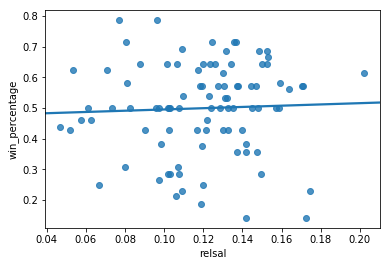

In [37]:
# Use sns.regol to see relationsip between salaries and win_percentage

sns.regplot(x='relsal', y='win_percentage', data=IPL_seasons, ci=False)

In [38]:
#relsal regression

reg1 = smf.ols(formula = 'win_percentage ~ relsal', data=IPL_seasons).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:         win_percentage   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.1622
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.688
Time:                        17:28:26   Log-Likelihood:                 45.259
No. Observations:                  92   AIC:                            -86.52
Df Residuals:                      90   BIC:                            -81.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4752      0.063      7.563      0.0

In [39]:
IPL_seasons = IPL_seasons.sort_values(by=['team','year'], ascending=True)

In [40]:
IPL_seasons['win_percent_lag'] = IPL_seasons.groupby('team')['win_percentage'].shift(1)

In [41]:
IPL_seasons

,year,team,team_salaries_season,total_salaries_season,relsal,total_played_season,total_won_season,total_noresult_season,win_percentage,win_percent_lag
0,2008,Chennai Super Kings,5825000,34105000,0.170796,14,8,0,0.571429,NaN
8,2009,Chennai Super Kings,6765000,33445000,0.202272,14,8,1,0.615385,0.571429
16,2010,Chennai Super Kings,4890000,33075000,0.147846,14,7,0,0.500000,0.615385
24,2011,Chennai Super Kings,6330000,62210000,0.101752,14,9,0,0.642857,0.500000
34,2012,Chennai Super Kings,7900000,59706250,0.132314,16,8,1,0.533333,0.642857
...,...,...,...,...,...,...,...,...,...,...
59,2014,Sunrisers Hyderabad,9803333,73973332,0.132525,14,6,0,0.428571,0.625000
67,2015,Sunrisers Hyderabad,8104667,65242665,0.124223,14,7,0,0.500000,0.428571
75,2016,Sunrisers Hyderabad,8747666,63483666,0.137794,14,8,0,0.571429,0.500000
83,2017,Sunrisers Hyderabad,8200500,63014833,0.130136,14,8,1,0.615385,0.571429


In [42]:
reg_2 = smf.ols(formula = 'win_percentage ~ relsal + win_percent_lag', data=IPL_seasons).fit()
print(reg_2.summary())

                            OLS Regression Results                            
Dep. Variable:         win_percentage   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.591
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.210
Time:                        17:29:23   Log-Likelihood:                 43.314
No. Observations:                  79   AIC:                            -80.63
Df Residuals:                      76   BIC:                            -73.52
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3489      0.087     

In [43]:
reg_3 = smf.ols(formula = 'win_percentage ~ relsal + win_percent_lag + C(team)', data=IPL_seasons).fit()
print(reg_3.summary())

                            OLS Regression Results                            
Dep. Variable:         win_percentage   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.157
Method:                 Least Squares   F-statistic:                     2.117
Date:                Tue, 19 Aug 2025   Prob (F-statistic):             0.0245
Time:                        17:29:28   Log-Likelihood:                 55.639
No. Observations:                  79   AIC:                            -83.28
Df Residuals:                      65   BIC:                            -50.10
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------

In [44]:
IPL_seasons['total_salaries_season'][IPL_seasons['year'] ==2014]

52    73973332
53    73973332
54    73973332
55    73973332
56    73973332
57    73973332
58    73973332
59    73973332
Name: total_salaries_season, dtype: int64